<a href="https://colab.research.google.com/github/CienciaDatosUdea/005_CCA_Estudiantes/blob/main/Sesiones/Sesion08_KL_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



In [1]:
!pip install datascience

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 725.1/725.1 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 38.0 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pylab as plt
from datascience import *
from itertools import product
%matplotlib inline


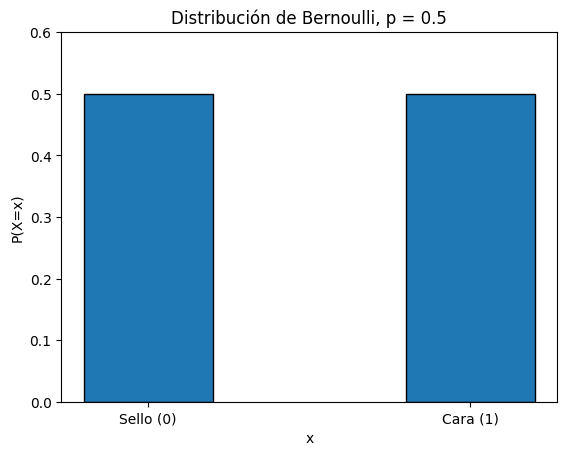

In [3]:

p = 0.5
n = 1000
x = np.array([0, 1])
# Distribución teórica
P = p**x * (1-p)**(1-x)
# Gráfico
plt.bar(x, P, width=0.4)

plt.xticks([0, 1], ["Sello (0)", "Cara (1)"])
plt.ylim(0, 0.6)
plt.xlabel("x")
plt.ylabel("P(X=x)")
plt.title("Distribución de Bernoulli, p = 0.5")
plt.show()

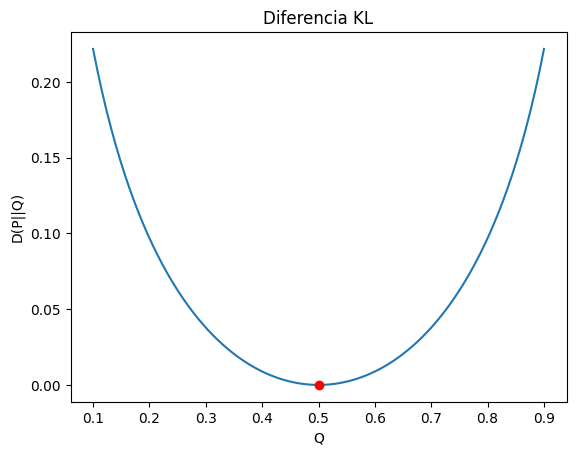

In [4]:
# Diferencia sin muestreo entre distrubuciones teoricas
Pteorico=make_array(0.5, 0.5)
#Qempirico=make_array(0.2, 0.5)

Qempirico = np.linspace(0.1, 0.9, 100 )
Pi = Pteorico

Dkl=[]
for q in Qempirico:
  Qi = q
  Dkl.append(Pi[0]*np.log10(Pi[0]/Qi) + (1-Pi[0])*np.log10( (1-Pi[0])/(1-Qi)))
DKL_ = np.array(Dkl)


plt.figure()
plt.plot(Qempirico, DKL_ )
plt.plot(0.5,0.0, "ro" )
plt.xlabel("Q")
plt.ylabel("D(P||Q)")
plt.title("Diferencia KL")
plt.show()

In [5]:
P=make_array(0.5, 0.5)
Prop = sample_proportions(100, P)
Prop

array([ 0.43,  0.57])

Text(0.5, 1.0, 'DKL = 0.005308256401205128')

<Figure size 400x400 with 0 Axes>

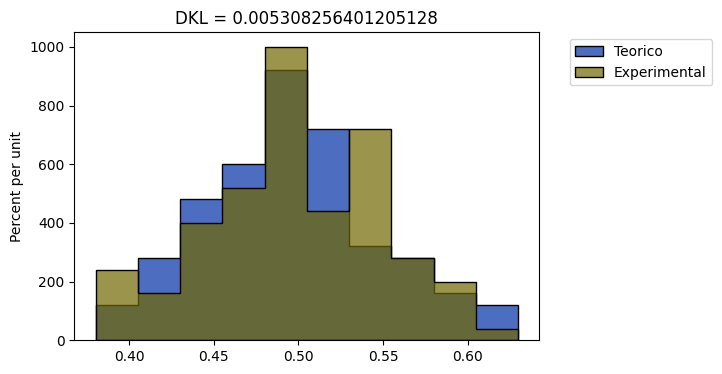

In [6]:
def multiples_experimentos(P, N=100):
  q=[]
  for i in range(0, N):
    Prop = sample_proportions(100, P)
    q.append(Prop[0])
  return np.array(q)

plt.figure(figsize=(4, 4))
P=make_array(0.5, 0.5)
Teorica = multiples_experimentos(P)
Q=make_array(0.5, 0.5)
Exp = multiples_experimentos(Q)

DKL = []
for q in Exp:
    d = (P[0] * np.log(P[0] / q)+ P[1] * np.log(P[1] / (1-q)))
    DKL.append(d)

DKL = np.array(DKL)
DKL_media = np.mean(DKL)

Table().with_columns("Teorico", Teorica,"Experimental", Exp).hist()
plt.title(f"DKL = {DKL_media:2}")

In [10]:
def promedio_DKL_experimental(N, P, Q):

  Pteorico = multiples_experimentos(P, N)
  Qexperimental = multiples_experimentos(Q, N)
  Moneda = Table().with_columns("Teorico", Pteorico,"Experimental", Qexperimental)

  DKL = Pteorico*np.log(Pteorico/Qexperimental) + (1-Pteorico)*np.log((1-Pteorico)/(1-Qexperimental))
  Dnp = np.array(DKL)
  return np.mean(Dnp)

In [11]:
zz=np.linspace(0.1, 0.9)
KL=[]
for z in zz:
  P = make_array(0.5,0.5)
  Q = make_array(z,1-z)
  KL.append(promedio_DKL_experimental(100, P , Q))


/tmp/ipykernel_484/3615877895.py:7: RuntimeWarning: divide by zero encountered in divide
  DKL = Pteorico*np.log(Pteorico/Qexperimental) + (1-Pteorico)*np.log((1-Pteorico)/(1-Qexperimental))


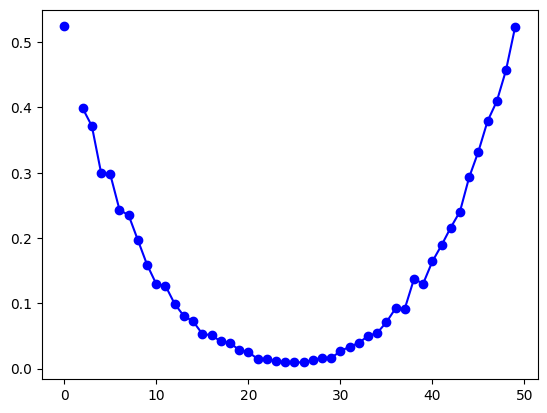

In [12]:
plt.plot(np.array(KL),"b-o")

\begin{equation}
D_{KL}(p_{data}||p_{\theta}) = \int p_{data}(x) \log \left( \frac{p_{data}}{p_{\theta}}\right)
\end{equation}


\begin{equation}
D_{KL}(p_{data}||p_{\theta}) = \int p_{data}(x) \log p_{data}(x)- \int p_{data}(x)\log p_{\theta}(x)
\end{equation}



\begin{equation}
D_{KL}(p_{data}||p_{\theta}) = E_{p_{data}} [p_{data}(x)]-E_{p_{data}} [p_{\theta}(x)]
\end{equation}

Minimizar KL, es equivalente a maximiar likehood

# Modelo de Transformer

In [13]:
frases = [
    # GATO
    "animal gato vive en casa sonido maulla",
    "animal gato duerme todo dia sonido maulla",
    "animal gato camina muy lento sonido maulla",
    "animal gato juega en casa sonido maulla",
    "animal gato come en cocina sonido maulla",
    "animal gato mira la ventana sonido maulla",
    "animal gato salta sobre mesa sonido maulla",
    "animal gato corre por casa sonido maulla",
    "animal gato descansa en sofa sonido maulla",
    "animal gato bebe mucha agua sonido maulla",

    # PERRO
    "animal perro vive en casa sonido ladra",
    "animal perro duerme todo dia sonido ladra",
    "animal perro camina muy lento sonido ladra",
    "animal perro juega en casa sonido ladra",
    "animal perro come en cocina sonido ladra",
    "animal perro mira la ventana sonido ladra",
    "animal perro salta sobre mesa sonido ladra",
    "animal perro corre por casa sonido ladra",
    "animal perro descansa en sofa sonido ladra",
    "animal perro bebe mucha agua sonido ladra",

    # VACA
    "animal vaca vive en campo sonido muge",
    "animal vaca duerme todo dia sonido muge",
    "animal vaca camina muy lento sonido muge",
    "animal vaca juega en campo sonido muge",
    "animal vaca come mucho pasto sonido muge",
    "animal vaca mira la montaña sonido muge",
    "animal vaca pasa por campo sonido muge",
    "animal vaca corre por campo sonido muge",
    "animal vaca descansa en campo sonido muge",
    "animal vaca bebe mucha agua sonido muge",

    # PATO
    "animal pato vive en lago sonido grazna",
    "animal pato duerme todo dia sonido grazna",
    "animal pato camina muy lento sonido grazna",
    "animal pato juega en lago sonido grazna",
    "animal pato come cerca lago sonido grazna",
    "animal pato mira el agua sonido grazna",
    "animal pato nada por lago sonido grazna",
    "animal pato corre por campo sonido grazna",
    "animal pato descansa en lago sonido grazna",
    "animal pato bebe mucha agua sonido grazna",
]

import torch
import torch.nn as nn

# Construimos el vocabulario
palabras = sorted(set(" ".join(frases).split()))

stoi = {palabra: i for i, palabra in enumerate(palabras)}
itos = {i: palabra for palabra, i in stoi.items()}

vocab_size = len(stoi)

print("Tamaño vocabulario:", vocab_size)
print(stoi)

Tamaño vocabulario: 44
{'agua': 0, 'animal': 1, 'bebe': 2, 'camina': 3, 'campo': 4, 'casa': 5, 'cerca': 6, 'cocina': 7, 'come': 8, 'corre': 9, 'descansa': 10, 'dia': 11, 'duerme': 12, 'el': 13, 'en': 14, 'gato': 15, 'grazna': 16, 'juega': 17, 'la': 18, 'ladra': 19, 'lago': 20, 'lento': 21, 'maulla': 22, 'mesa': 23, 'mira': 24, 'montaña': 25, 'mucha': 26, 'mucho': 27, 'muge': 28, 'muy': 29, 'nada': 30, 'pasa': 31, 'pasto': 32, 'pato': 33, 'perro': 34, 'por': 35, 'salta': 36, 'sobre': 37, 'sofa': 38, 'sonido': 39, 'todo': 40, 'vaca': 41, 'ventana': 42, 'vive': 43}


In [16]:
import numpy as np
import keras
from keras import layers
import math

In [20]:
class AtencionCausal(layers.Layer):

    def __init__(self, d_model, n_cabezas=2, **kwargs):
        super().__init__(**kwargs)
        assert d_model % n_cabezas == 0
        self.d_model = d_model
        self.n_cabezas = n_cabezas
        self.d_k = d_model // n_cabezas
        self.wq = layers.Dense(d_model, name="wq")
        self.wk = layers.Dense(d_model, name="wk")
        self.wv = layers.Dense(d_model, name="wv")
        self.wo = layers.Dense(d_model, name="wo")

    def _separar_cabezas(self, x, batch, seq_len):
        x = keras.ops.reshape(x,(batch, seq_len, self.n_cabezas, self.d_k))
        return keras.ops.transpose(x,(0, 2, 1, 3))

    def call(self, x):
        batch = keras.ops.shape(x)[0]
        seq_len = keras.ops.shape(x)[1]
        Q = self._separar_cabezas(self.wq(x), batch, seq_len)
        K = self._separar_cabezas(self.wk(x), batch, seq_len)
        V = self._separar_cabezas(self.wv(x), batch, seq_len)
        # Q K^T
        scores = keras.ops.matmul(Q,keras.ops.transpose(K, (0, 1, 3, 2)))
        scores = scores / math.sqrt(self.d_k)
        # ---------------------
        # máscara causal
        # ---------------------
        i = keras.ops.arange(seq_len)[:, None]
        j = keras.ops.arange(seq_len)[None, :]
        mascara = j > i
        scores = keras.ops.where(mascara,-1e9,scores)
        # softmax
        pesos = keras.ops.softmax(scores,axis=-1  )
        # A V
        salida = keras.ops.matmul(pesos,V)
        # juntar nuevamente las cabezas
        salida = keras.ops.transpose(salida,(0, 2, 1, 3))
        salida = keras.ops.reshape(salida,(batch, seq_len, self.d_model))
        salida = self.wo(salida)
        return salida, pesos

In [22]:
class EmbedPosicional(layers.Layer):
    def __init__(self, seq_len, d_model, **kwargs):
        super().__init__(**kwargs)
        self.pos_emb = layers.Embedding(seq_len,d_model)

    def call(self, x):
        seq_len = keras.ops.shape(x)[1]
        posiciones = keras.ops.arange(seq_len)
        return x + self.pos_emb(posiciones)

In [23]:
class BloqueTransformer(layers.Layer):

    def __init__(self,d_model,n_cabezas,d_ff,**kwargs):
        super().__init__(**kwargs)
        self.atencion = AtencionCausal(d_model,n_cabezas)

        self.norm1 = layers.LayerNormalization()
        self.ffn = keras.Sequential([layers.Dense(d_ff,activation="relu"),layers.Dense(d_model)])
        self.norm2 = layers.LayerNormalization()


    def call(self, x):
        atn_out, pesos = self.atencion(x)
        # residual 1
        x = self.norm1(x + atn_out)

        # FFN + residual 2
        x = self.norm2(x + self.ffn(x))
        return x, pesos

In [49]:
# vocabulario
palabras = sorted(set(" ".join(frases).split()))
stoi = {palabra: i for i, palabra in enumerate(palabras)}
itos = {i: palabra for palabra, i in stoi.items()}
vocab_size = len(stoi)

In [51]:
# ------------------------
# construir X e Y
# ------------------------
X = []
Y = []
for frase in frases:
    ids = [
        stoi[p]
        for p in frase.split()
    ]
    X.append(ids[:-1])
    Y.append(ids[1:])
X = np.array(X, dtype="int32")
Y = np.array(Y, dtype="int32")
print(X.shape)
print(Y.shape)

(40, 6)
(40, 6)


In [52]:
for frase in frases[:4]:
    palabras_frase = frase.split()
    ids = [stoi[p] for p in palabras_frase]
    x_ids = ids[:-1]
    y_ids = ids[1:]
    x_palabras = [itos[i] for i in x_ids]
    y_palabras = [itos[i] for i in y_ids]
    print("Frase original:")
    print(frase)
    print("\nX:")
    print(" ".join(x_palabras))
    print("\nY:")
    print(" ".join(y_palabras))
    print("-" * 60)

Frase original:
animal gato vive en casa sonido maulla

X:
animal gato vive en casa sonido

Y:
gato vive en casa sonido maulla
------------------------------------------------------------
Frase original:
animal gato duerme todo dia sonido maulla

X:
animal gato duerme todo dia sonido

Y:
gato duerme todo dia sonido maulla
------------------------------------------------------------
Frase original:
animal gato camina muy lento sonido maulla

X:
animal gato camina muy lento sonido

Y:
gato camina muy lento sonido maulla
------------------------------------------------------------
Frase original:
animal gato juega en casa sonido maulla

X:
animal gato juega en casa sonido

Y:
gato juega en casa sonido maulla
------------------------------------------------------------


$H(0)=[hanimal​,hgato​,hvive​,hen​,hcasa​,hsonido​],$

- `seq_len = X.shape[1]`  
  Número de tokens por secuencia $seq\_len = 6$
  

- `d_model = 6`  
  Dimensión del vector que representa cada token $h_i \in \mathbb{R}^6$.
  

- `n_cabezas = 2`  
  Número de mecanismos de atención que trabajan en paralelo.

  Como:

  \begin{equation}
  d_k = \frac{d_{model}}{n_{cabezas}}
  \end{equation}

  entonces:

  \begin{equation}
  d_k = \frac{6}{2} = 3
  \end{equation}

  Tenemos:

  \begin{equation}
  \text{Cabeza 1}: Q_1, K_1, V_1
  \end{equation}

  \begin{equation}
  \text{Cabeza 2}: Q_2, K_2, V_2
  \end{equation}

  Cada cabeza calcula:

  \begin{equation}
  A_i =
  \operatorname{softmax}
  \left(
  \frac{Q_iK_i^T}{\sqrt{3}} + M
  \right)V_i
  \end{equation}

  Luego se concatenan las dos cabezas $A_1 \; || \; A_2$:

  y se vuelve a una representación de dimensión 6.

- `d_ff = 24`  
  Dimensión interna de la red neuronal feed-forward: $6 \rightarrow 24 \rightarrow 6$


In [53]:
seq_len = X.shape[1]
d_model = 6
n_cabezas = 2
d_ff = 24

In [54]:
entrada = keras.Input(shape=(seq_len,),dtype="int32")
# embedding de palabras
x = layers.Embedding(vocab_size,d_model,name="token_embedding")(entrada)
# embedding posicional
x = EmbedPosicional(seq_len,d_model,name="pos_embedding")(x)
x

<KerasTensor shape=(None, 6, 6), dtype=float32, sparse=False, ragged=False, name=keras_tensor_17>

In [55]:
# Transformer
x, pesos = BloqueTransformer(d_model=d_model,n_cabezas=n_cabezas,d_ff=d_ff,name="transformer")(x)
# de H^(1) al vocabulario
logits = layers.Dense(vocab_size,name="salida_vocabulario")(x)

In [56]:
modelo = keras.Model(entrada,logits)
modelo.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_embedding (Embedding)     │ (None, 6, 6)           │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pos_embedding (EmbedPosicional) │ (None, 6, 6)           │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer (BloqueTransformer) │ [(None, 6, 6), (None,  │           510 │
│                                 │ 2, 6, 6)]              │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida_vocabulario (Dense)      │ (None, 6, 44)          │           308 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,118 (4.37 KB)

 Trainable params: 1,118 (4.37 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
modelo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss=keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),
    metrics=["accuracy"]
)

In [ ]:
historia = modelo.fit(
    X,
    Y,
    epochs=200,
    batch_size=8,
    verbose=0
)

In [ ]:
print(
    "Loss final:",
    historia.history["loss"][-1]
)

print(
    "Accuracy final:",
    historia.history["accuracy"][-1]
)

Loss final: 0.625357449054718
Accuracy final: 0.720833420753479


In [ ]:
frase_test = (
    "animal gato vive en casa sonido"
)

ids_test = [
    stoi[p]
    for p in frase_test.split()
]

x_test = np.array(
    [ids_test],
    dtype="int32"
)

logits_test = modelo.predict(
    x_test,
    verbose=0
)

In [ ]:
logits_ultima = logits_test[0, -1]

probabilidades = keras.ops.softmax(
    logits_ultima
)

probabilidades = np.array(probabilidades)

In [ ]:
id_predicho = np.argmax(
    probabilidades
)

palabra_predicha = itos[id_predicho]

print(
    "Predicción:",
    palabra_predicha
)

Predicción: maulla


In [ ]:
def predecir_sonido(animal):

    frase = (
        f"animal {animal} "
        "vive en casa sonido"
    )

    ids = [
        stoi[p]
        for p in frase.split()
    ]

    x = np.array(
        [ids],
        dtype="int32"
    )

    logits = modelo.predict(
        x,
        verbose=0
    )

    probs = np.array(
        keras.ops.softmax(
            logits[0, -1]
        )
    )

    idx = np.argmax(probs)

    return itos[idx], probs[idx]

In [ ]:
print(predecir_sonido("gato"))
print(predecir_sonido("perro"))

('maulla', np.float32(0.99751186))
('ladra', np.float32(0.99672854))
